# Figure 4: Multiple occluders

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-06-11 12:15:46,935::INFO::settings.py::Setting loglevel to INFO
2025-06-11 12:15:46,938::INFO::settings.py::Setting stores to {}
2025-06-11 12:15:46,938::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-06-11 12:15:46,939::INFO::settings.py::Setting database.misc.create_tables to True
2025-06-11 12:15:46,939::INFO::settings.py::Setting enable_python_native_blobs to True
2025-06-11 12:15:46,940::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-06-11 12:15:46,940::INFO::settings.py::Setting database.user to thomas
2025-06-11 12:15:46,941::INFO::settings.py::Setting database.password to thomas_mathislab
2025-06-11 12:15:47,129::INFO::connection.py::Connected thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-06-11 12:15:47,237::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:47,735::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:47,735::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:48,594::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:48,594::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:48,750::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:48,750::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:49,074::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:49,074::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:49,440::INFO::table.py::could not log event in table ~log
2025-06-11 12:15:49,440::INFO::table.py::could not log event in table ~log


In [43]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc, vr4mice
from vr4mice.analysis import utils
from vr4mice.schema.vr4mice import Groups, Labels
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, YBinnedXYTrajectory, MeanVelocities
from vr4mice.analysis.analysis import mean_xy_trajectory
from vr4mice.analysis.stats import get_p_values_multi, get_multi_performance_p_val, plot_aperture_heatmap

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
trial_df = (Groups() * (Labels()  & 'label = "ar_paper"') * (vr4mice.Dataset() & 'session_label = "ar_discrim_5_occluders"') * TrialMetrics()).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.multi_occluder_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]], threshold_drop=.25, return_excluded=False)
# Create list of included datasets

mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

Excluded datasets:  ['31726_2025-03-25_1' '31726_2025-03-26_1' '31728_2025-03-10_1'
 '31728_2025-03-12_1' '31728_2025-03-17_1' 'Jacana_2024-08-20_1'
 'Lemming_2024-08-16_1' 'Oribi_2024-08-23_1' 'Oribi_2024-08-28_1'
 'Pheasant_2024-08-23_1' 'Pheasant_2024-08-27_2']


2025-06-11 14:23:24,483::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:23:24,483::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:23:24,488::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:23:24,488::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:23:24,529::INFO::category.py::Using categorical un

AttributeError: 'Series' object has no attribute 'columns'

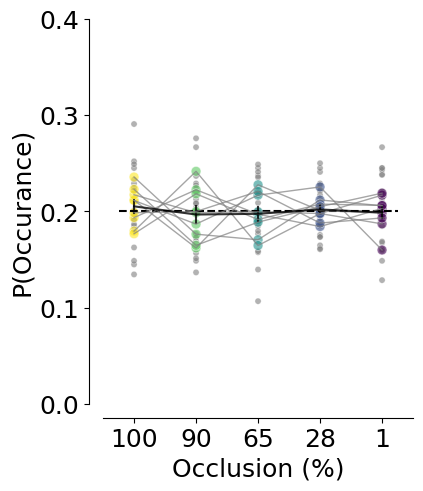

In [ ]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(4, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_multi_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.2,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 0.4)
plt.xlim(-0.5, 4.5)
plt.xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

plt.xlabel("Occlusion (%)")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure4_multi_occluder_trial_number.svg", transparent=True)

#counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])


"""
for i in counts.probability.columns:
    print(
        f"{i}: ",
        np.mean(np.array(counts["probability"][i])),
        "std: ",
        np.std(np.array(counts["probability"][i])),
    )
    for j in counts.probability.columns:
        if i < j:
            stat = ttest_rel(
                np.array(counts["probability"][i]), np.array(counts["probability"][j])
            )
            print(f"{i}-{j}: {stat}")"""

2025-06-11 14:24:19,793::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:24:19,793::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:24:19,801::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:24:19,801::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-11 14:24:19,894::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=-2.0910925580108795, pvalue=0.04728248861079895, df=24)
3.0-6.0: TtestResult(statistic=-4.830965673377193, pvalue=6.38319530380985e-05, df=24)
3.0-8.48: TtestResult(statistic=-5.523879283374772, pvalue=1.1104543950005748e-05, df=24)
4.2-6.0: TtestResult(statistic=-2.199927768181941, pvalue=0.03768255574071594, df=24)
4.2-8.48: TtestResult(statistic=-2.968397820508206, pvalue=0.006688811903391687, df=24)
6.0-8.48: TtestResult(statistic=-0.5058276197992468, pvalue=0.6175922888247101, df=24)
12.0-3.0: TtestResult(statistic=4.7890505894611985, pvalue=7.100502711101454e-05, df=24)
12.0-4.2: TtestResult(statistic=2.2316212656801184, pvalue=0.03523885609626643, df=24)
12.0-6.0: TtestResult(statistic=0.045502649901139954, pvalue=0.9640831640660874, df=24)
12.0-8.48: TtestResult(statistic=-0.6873382392150224, pvalue=0.498458549120927, df=24)
              mean       sem
aperture                    
12.0      0.891895  0.018587
3.0       0.749104  0.021262
4.2     

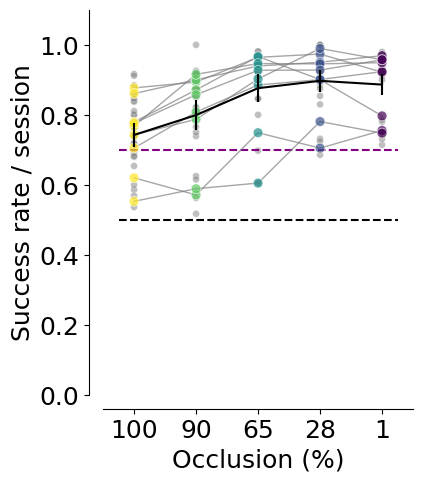

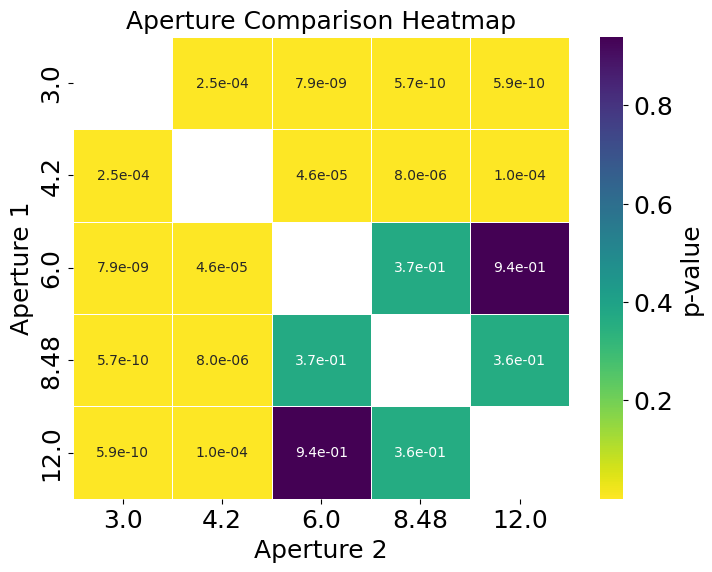

<Figure size 640x480 with 0 Axes>

In [66]:
# Success rate per mouse (new)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / session")
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

plt.legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_performance_p_val(trial_df,  y_var="trial_rewarded")
plot_aperture_heatmap(p_values)

plt.savefig(save_fig_path + "figure4_multi_occluder_rewards.svg", transparent=True)

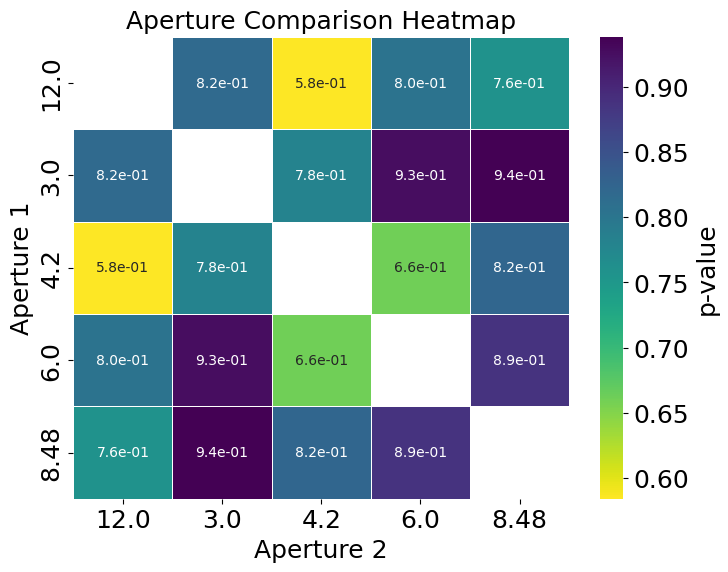

# Trajectory analysis

In [8]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:    
    print(d)
    try:
        if len(MeanXYTrajectory() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((MeanXYTrajectory() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df ["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-27_1
31726_2025-03-28_1
31728_2025-03-11_1
31728_2025-03-14_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [9]:
mean_xy = mean_xy_trajectory(interpolated_df, index_columns=["aperture", "trial_left_choice", "trial_length"])

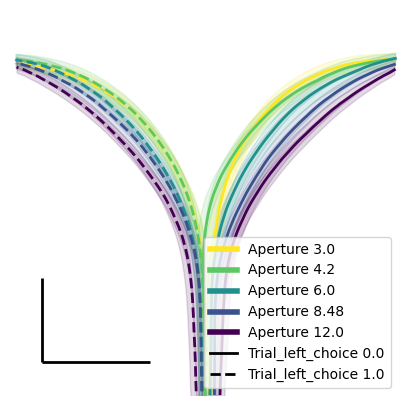

In [10]:
plotting.plot_mean_xy_trajectory(mean_xy, cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
plt.savefig(save_fig_path + "multioccluder_trajectories_time.svg", transparent=True)

In [11]:
mean_mouse_xy = mean_xy_trajectory(interpolated_df, index_columns=["aperture", "mouse_name" ,"trial_left_choice", "trial_length"])

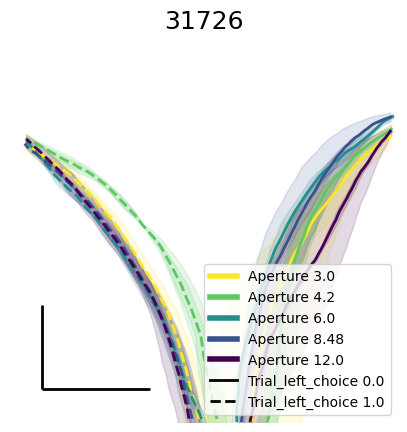

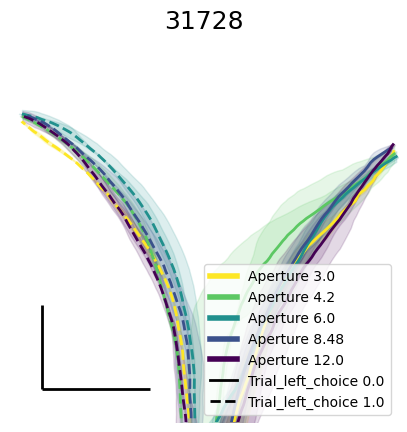

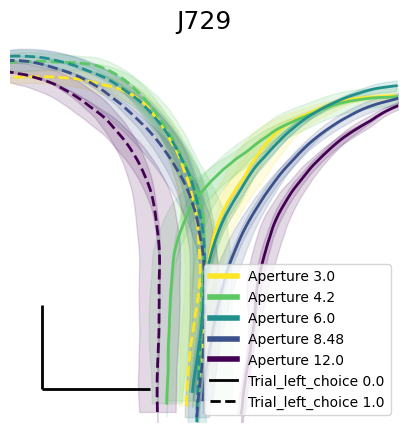

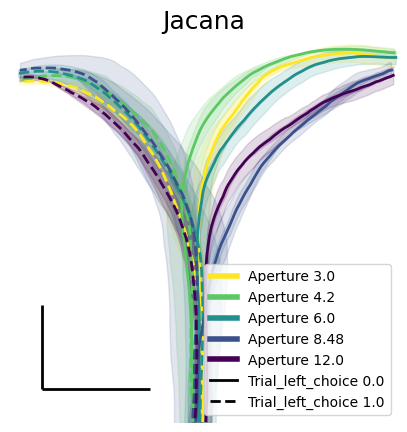

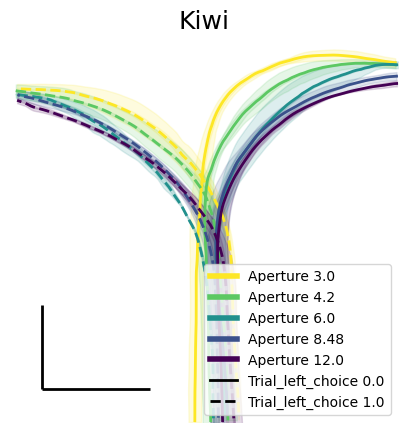

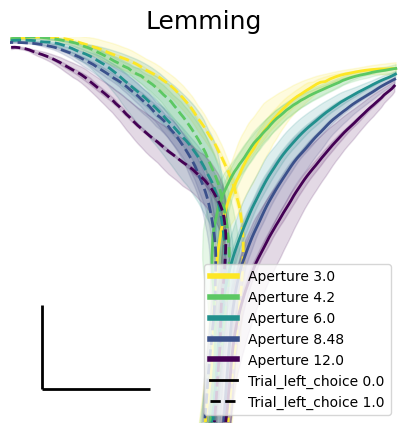

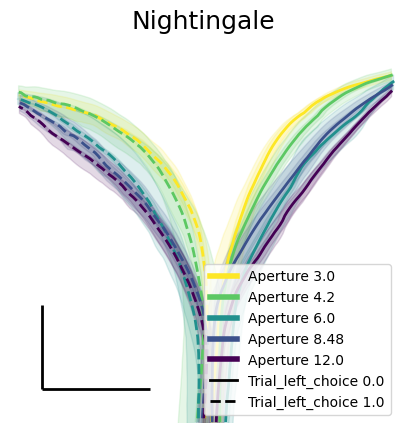

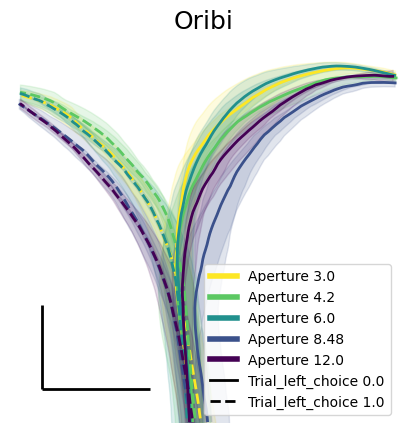

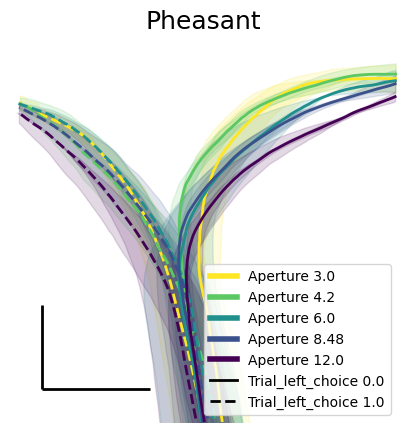

In [12]:
for m in mean_mouse_xy.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse_xy[mean_mouse_xy.mouse_name == m], cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(m)
    plt.savefig(save_fig_path + f"multioccluder_trajectories_time_{m}.svg", transparent=True)

# Stats on trajectories

In [25]:
# takes 2 min to fetch
inter_df = []
for m in mouse_list:
    try:
        #print(m)
        inter_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
    except Exception as err:
        print(err)
inter_df = pd.concat(inter_df)

aperture_to_occlusion = {
    12.0: 100,
    8.48: 90,
    6.0: 65,
    4.2: 28,
    3.0: 1
}

# Map the values
inter_df ['aperture'] = inter_df['aperture'].map(aperture_to_occlusion)


inter_df ["mouse_name"] = inter_df.dataset.str.split("_").str [0]
inter_df ["x_flipped"] = inter_df.x * inter_df.flip_one_side
data = utils.create_bins(inter_df [inter_df.trial_rewarded == 1.0].copy())

mean_mouse = (
    data.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)

mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

Text(0, 0.5, 'X position')

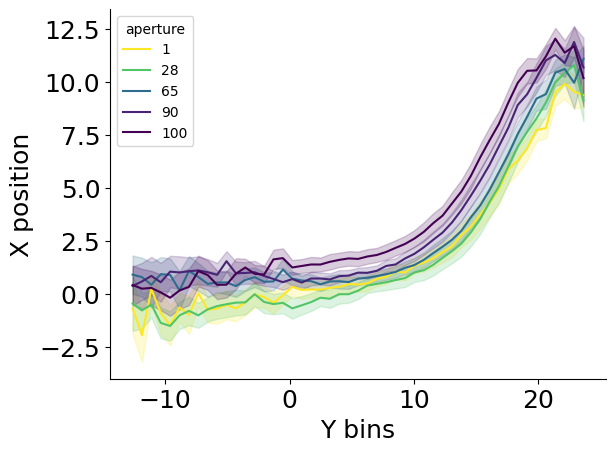

In [26]:
sns.lineplot(data = mean_mouse, x="bin_centers", y="x_flipped", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Y bins")
plt.ylabel("X position")

In [27]:
mean_mouse = mean_mouse [(mean_mouse.bin_centers > -2) & (mean_mouse.bin_centers < 19)]
print(
    AnovaRM(
        data=mean_mouse,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture               8.8332   4.0000   96.0000 0.0000
bin_centers          124.6787  26.0000  624.0000 0.0000
aperture:bin_centers   4.3914 104.0000 2496.0000 0.0000



In [23]:
p_value_df = get_p_values_multi(mean_mouse, x_var="bin_centers", y_var="x_flipped")

Text(0.5, 0, 'y bin')

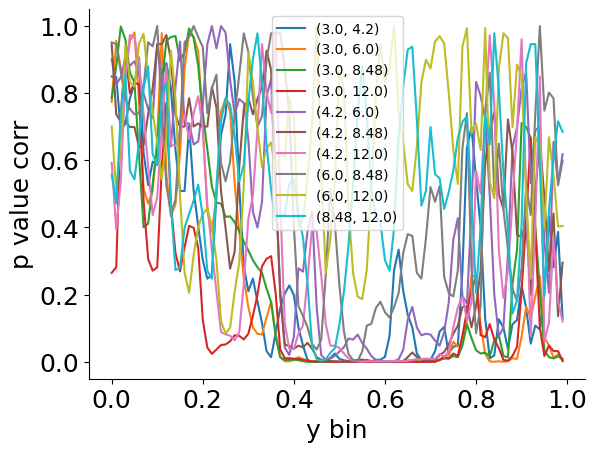

In [ ]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))
plt.ylabel("p value corr")
plt.xlabel("y bin")

In [ ]:
p_value_df.pivot(index = "bin", columns=["aperture1", "aperture2"], values=["p_value_corr"])

p_value_corr                                                    \
aperture1         3.00                                    4.20             
aperture2        4.20      6.00      8.48      12.00     6.00      8.48    
bin                                                                        
0.00          0.848580  0.772832  0.784108  0.264738  0.899229  0.944409   
0.01          0.846719  0.954850  0.879623  0.281681  0.824143  0.736183   
0.02          0.686216  0.871023  0.997124  0.736006  0.846719  0.713680   
0.03          0.708765  0.846062  0.959130  0.917963  0.904142  0.715030   
0.04          0.782973  0.954850  0.860172  0.798158  0.880271  0.698286   
...                ...       ...       ...       ...       ...       ...   
0.95          0.207680  0.073523  0.034021  0.017706  0.357281  0.489038   
0.96          0.432876  0.048688  0.014338  0.048781  0.205554  0.271126   
0.97          0.281447  0.013724  0.010341  0.032172  0.654228  0.441465   
0.98          0.386548  0.022009  0.016459  0.032172  0.530777  0.135974   
0.99          0.129429  0.004160  0.009290  0.002542  0.617428  0.295400   

                                                   
aperture1                6.00                8.48  
aperture2     12.00     8.48      12.00     12.00  
bin                                                
0.00       0.591855  0.950002  0.699965  0.557451  
0.01       0.393255  0.944687  0.508204  0.470747  
0.02       0.537353  0.862636  0.654228  0.742705  
0.03       0.848580  0.781412  0.944409  0.854239  
0.04       0.971735  0.751783  0.832351  0.567757  
...             ...       ...       ...       ...  
0.95       0.059564  0.747000  0.398494  0.197592  
0.96       0.117096  0.800725  0.668205  0.451648  
0.97       0.366741  0.783838  0.557099  0.607867  
0.98       0.181275  0.525084  0.402200  0.715198  
0.99       0.120180  0.598763  0.404205  0.683909  

[100 rows x 10 columns]

# Velocity analysis

In [22]:
velocity_df = []
for m in mouse_list:
    #print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

mean_mouse = velocity_df.groupby(["dataset", "aperture", "trial_length"],as_index=False).mean()

Text(0, 0.5, 'Velocity')

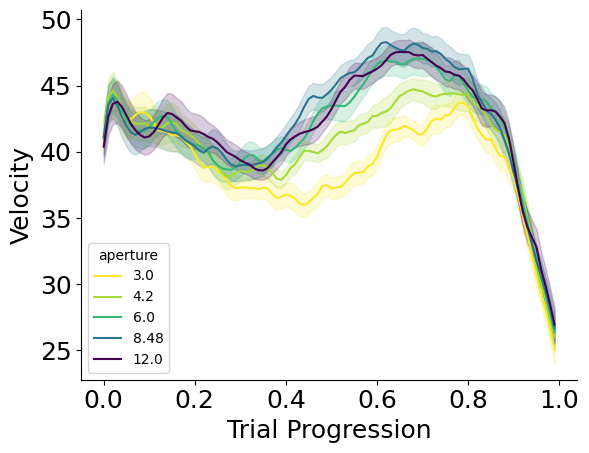

In [ ]:
sns.lineplot(data = mean_mouse, x="trial_length", y="velocity", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Trial Progression")
plt.ylabel("Velocity")

In [ ]:
p_value_df = get_p_values_multi(mean_mouse, x_var="bin_centers", y_var="x_flipped")

Text(0.5, 0, 'y bin')

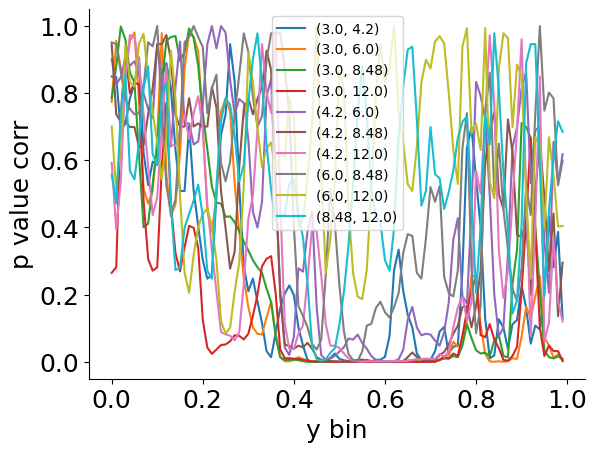

In [ ]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))
plt.ylabel("p value corr")
plt.xlabel("y bin")

# Below this is the old code

**Interpretation**

Since all p-values are very small (0.0000), we can conclude that both aperture and bin_centers significantly influence x_flipped, and their interaction is also significant. This means that the effect of aperture on x_flipped depends on bin_centers.

In [ ]:
multi_occluder = [
    # Mathis lab
    {"dataset": "Nightingale_2024-08-15_1"},
    {"dataset": "Nightingale_2024-08-16_1"},
    {"dataset": "Nightingale_2024-08-21_1"},
    {"dataset": "Nightingale_2024-08-22_1"},
    {"dataset": "Lemming_2024-08-14_1"},
    {"dataset": "Lemming_2024-08-15_1"},
    {"dataset": "Lemming_2024-08-16_1"},
    {"dataset": "Lemming_2024-08-19_1"},
    {"dataset": "Jacana_2024-08-20_1"},
    {"dataset": "Jacana_2024-08-21_1"},
    {"dataset": "Jacana_2024-08-22_1"},
    {"dataset": "Kiwi_2024-08-19_1"},
    {"dataset": "Kiwi_2024-08-20_1"},
    {"dataset": "Kiwi_2024-08-21_1"},
    {"dataset": "Pheasant_2024-08-23_1"},
    {"dataset": "Pheasant_2024-08-26_1"},
    {"dataset": "Pheasant_2024-08-27_2"},
    {"dataset": "Pheasant_2024-08-28_1"},
    {"dataset": "Oribi_2024-08-23_1"},
    {"dataset": "Oribi_2024-08-26_1"},
    {"dataset": "Oribi_2024-08-27_1"},
    {"dataset": "Oribi_2024-08-28_1"},
    {"dataset": "Oribi_2024-08-29_1"},
    # Niell lab
    {"dataset": "J729_2024-12-11_1"},
    {"dataset": "J729_2024-12-12_1"},
    {"dataset": "J729_2024-12-13_1"},
    {"dataset": "J729_2024-12-15_1"},
]

multi_occluder = multi_occluder + multi_occluder_tolias
print(multi_occluder)


NameError: name 'multi_occluder_tolias' is not defined

In [ ]:
for d in multi_occluder:
    print(d ["dataset"])
    Groups().add(dataset=d["dataset"], label="ar_paper")

2025-06-06 09:07:52,320::INFO::table.py::could not log event in table ~log
2025-06-06 09:07:52,320::INFO::table.py::could not log event in table ~log


Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-16_1
Lemming_2024-08-19_1
Jacana_2024-08-20_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Pheasant_2024-08-23_1
Pheasant_2024-08-26_1
Pheasant_2024-08-27_2
Pheasant_2024-08-28_1
Oribi_2024-08-23_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-28_1
Oribi_2024-08-29_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
31728_2025-03-10_1
31728_2025-03-11_1
31728_2025-03-12_1
31728_2025-03-14_1
31728_2025-03-17_1
31726_2025-03-25_1
31726_2025-03-26_1
31726_2025-03-27_1
31726_2025-03-28_1


In [ ]:
tolias_lab = pd.read_pickle("multi_occluder_")
#niell_data = pd.read_pickle("big_df_contrast_multi_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_multi.pkl")
big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)
#big_df_pre_filtered = pd.read_pickle("mutli_occluder_all_labs.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'mutli_occluder_all_labs.pkl'

In [ ]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []

    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)

        offline_kinematics_df = dlc.OfflineKinematics().get_data(
            key=d,
            columns=["head_center_x", "head_center_y", "heading_dir", "head_angle"],
        )
        df = base_analysis.DataFrame().get_data(
            key=d,
            columns=[
                "dataset",
                "trial",
                "aperture",
                "trial_right_choice",
                "trial_left_choice",
                "velocity",
                "velocity_x",
                "velocity_y",
                "reward",
                "norm_y",
                "iti",
                "x",
                "y",
                "trial_init_x",
                "trial_init_y",
                "trial_tortuosity",
                "trial_duration",
            ],
        )
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)

        df = df.join(offline_kinematics_df)

        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage

        big_df.append(df)

    big_df = pd.concat(big_df).reset_index()
    big_df["session_increment"] = np.array(big_df.groupby("dataset").ngroup() + 1)
    big_df = big_df.infer_objects()

    return big_df.reset_index(drop=True)

In [ ]:
dfs = []
dual = (vr4mice.Dataset() & f'session_label = "ar_discrim_5_occluders"') & (
    vr4mice.Collab() & "idx=3"
)
dual_list = [{"dataset": x["dataset"]} for x in dual]
if {"dataset": "J731_2024-12-15_1"} in dual_list:
    # unclear to me why this data set is removed -
    dual_list.remove({"dataset": "J731_2024-12-15_1"})
print(dual_list)
big_df = get_all_in_list(data_set_list=dual_list, training_stage="ar_discrim_occluders")

[{'dataset': 'J729_2024-12-11_1'}, {'dataset': 'J729_2024-12-12_1'}, {'dataset': 'J729_2024-12-13_1'}, {'dataset': 'J729_2024-12-15_1'}]
ar_discrim_occluders
['J729', '2024-12-11', '1']


KeyboardInterrupt: 

In [ ]:
# Filter the data - no iti and only J_shaped trials
big_df = trial_df[trial_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)

mean_mouse = (
    j_shaped.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
    )
    .mean(numeric_only=True)
    .copy()
)

AttributeError: 'DataFrame' object has no attribute 'iti'

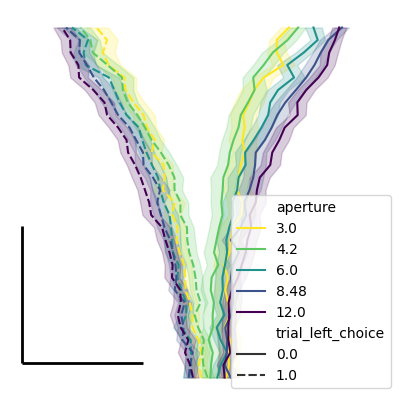

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x=mean_mouse.bin_centers,
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice
    if len(mean_mouse.aperture.unique()) == 2
    else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis("off")
#ax.legend([], [], frameon=False)
sns.despine(offset=10)
#plt.savefig(
#    save_fig_path + "figure4_multi_occluder_mean_trajectories.svg", transparent=True
#)

In [ ]:
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)
j_shaped = j_shaped
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped["x_flipped"] = j_shaped.x * j_shaped.flip_one_side
mean_mouse = (
    j_shaped.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)
mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

In [ ]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

ValueError: Data is unbalanced.

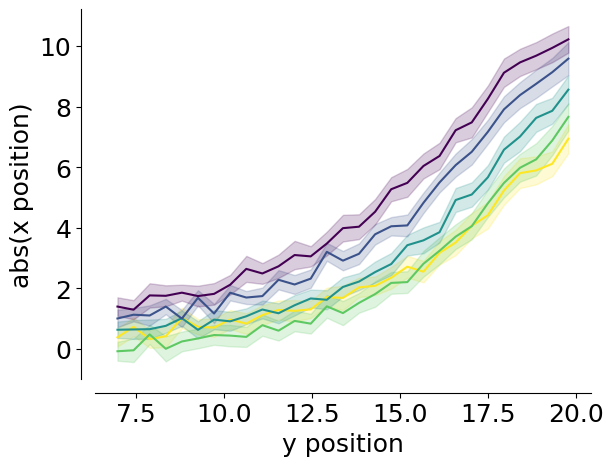

In [ ]:
sns.lineplot(
    data=mean_mouse,
    x="bin_centers",
    y="x_flipped",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
    alpha=1,
)

plt.ylabel("abs(x position)")
plt.xlabel("y position")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure4_position_flipped.svg", transparent=True)

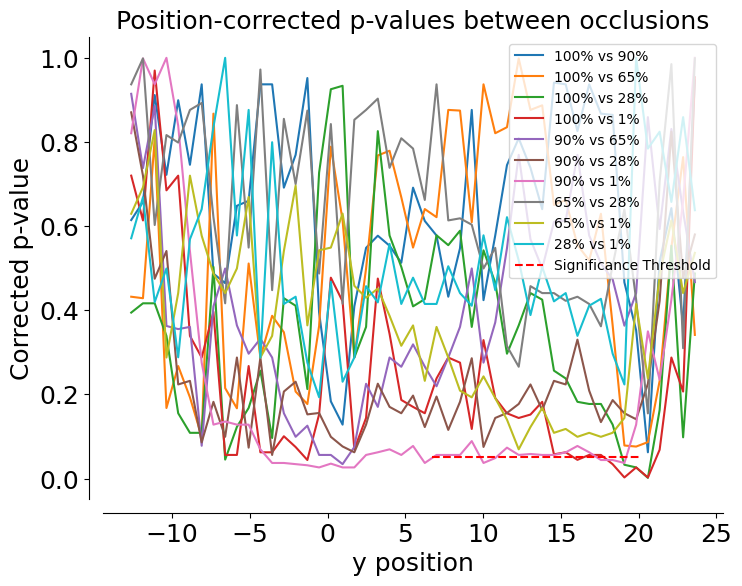

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as smm

p_values = []
apertures = y_binned_df.aperture.unique()
percentage_pairs = ["100%", "90%", "65%", "28%", "1%"]

pairwise_comparisons = list(
    itertools.combinations(apertures, 2)
)  # Generate all pairs of apertures
pairwise_percentage = list(
    itertools.combinations(percentage_pairs, 2)
)  # Generate all pairs of apertures

for i in y_binned_df.bin_centers.unique():
    section = y_binned_df[y_binned_df.bin_centers == i]

    for ap1, ap2 in pairwise_comparisons:
        t = ttest_ind(
            section[section.aperture == ap1].x_flipped,
            section[section.aperture == ap2].x_flipped,
        )

        p_values.append(
            pd.DataFrame(
                {"segment": i, "aperture_pair": f"{ap1} vs {ap2}", "p_value": t.pvalue},
                index=[0],
            )
        )

# Convert to DataFrame
p_value_df = pd.concat(p_values)

# Apply False Discovery Rate (FDR) correction across all comparisons
p_value_df["p_value_corr"] = smm.multipletests(p_value_df.p_value, method="fdr_bh")[1]

# Plot results for each aperture pair
plt.figure(figsize=(8, 6))
for pair, label_pair in zip(pairwise_comparisons, pairwise_percentage):
    subset = p_value_df[p_value_df.aperture_pair == f"{pair[0]} vs {pair[1]}"]
    plt.plot(
        subset.segment, subset.p_value_corr, label=f"{label_pair[0]} vs {label_pair[1]}"
    )

plt.hlines(
    0.05,
    xmin=6.75,
    xmax=20,
    color="red",
    linestyle="dashed",
    label="Significance Threshold",
)
plt.xlabel("y position")
plt.ylabel("Corrected p-value")
plt.title("Position-corrected p-values between occlusions")
plt.legend()
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure4_position_pvalue.svg", transparent=True)
plt.show()

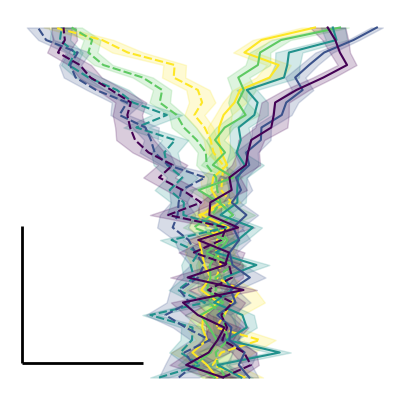

In [ ]:
# Example

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=j_shaped[j_shaped.dataset == "Kiwi_2024-08-19_1"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1]
    if len(mean_mouse.aperture.unique()) == 2
    else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)

ax.legend([], [], frameon=False)
plt.axis("off")
plt.savefig(
    save_fig_path + "figure4_multi_occluder_trajectories_example_session.svg",
    transparent=True,
)